# Getting up to speed with DRL

In this notebook I provide a simple example of implementing a policy gradient Deep Reinforcement Learning algorithm to solve a control problem with continuous state space and discrete action space -- the venerable [CartPole environment](https://gymnasium.farama.org/environments/classic_control/cart_pole/). You should study the implementation in this notebook in preparation for the laboratory next Wednesday.

This notebook should run in an environment with at least the following packages installed (the gpu version of PyTorch is not mandatory):

     conda create -n DRL -c conda-forge gymnasium pytorch-gpu matplotlib pygame jupyterlab
     
Some background reading to get you started:

1. We will be using the [Gymnasium](https://gymnasium.farama.org/) framework for all of our experiments. This framework provides a consistent interface to a broad range of reinforcement learning environments (including CartPole). You should familiarize yourself with how it works, how environments are specified, how to instantiate them, and how to interact with them.

2. [This excellent blog post](http://karpathy.github.io/2016/05/31/rl/) is a great introduction to policy gradients, where they come from and how they work. Give it a read and I am sure it will help understand better what is going on in this notebook.

## Preliminaries

We start with our standard imports.

In [1]:
# Standard imports.
import numpy as np
import matplotlib.pyplot as plt
import gymnasium
import torch
import torch.nn as nn
import torch.nn.functional as F

# Plus one non standard one -- we need this to sample from policies.
from torch.distributions import Categorical

# This *might* help PyGame crash less...
import pygame
_ = pygame.init()

And also some utility functions useful for what comes next.

In [2]:
# Given an environment, observation, and policy, sample from pi(a | obs). Returns the
# selected action and the log probability of that action (needed for policy gradient).
def select_action(env, obs, policy, temperature=1.0):
    dist = Categorical(policy(obs, temperature=temperature))
    action = dist.sample()
    log_prob = dist.log_prob(action)
    return (action.item(), log_prob.reshape(1))

# Utility to compute the discounted total reward. Torch doesn't like flipped arrays, so we need to
# .copy() the final numpy array. There's probably a better way to do this.
def compute_returns(rewards, gamma):
    return np.flip(np.cumsum([gamma**(i+1)*r for (i, r) in enumerate(rewards)][::-1]), 0).copy()

# Given an environment and a policy, run it up to the maximum number of steps.
def run_episode(env, policy, maxlen=500):
    observations = []
    actions = []
    log_probs = []
    rewards = []
    
    OBS_SCALE = torch.tensor([4.8, 5.0, 0.418, 5.0], dtype=torch.float32)
    
    (obs, info) = env.reset()
    for i in range(maxlen):
        obs = torch.tensor(obs, dtype=torch.float32) / OBS_SCALE
        (action, log_prob) = select_action(env, obs, policy)
        observations.append(obs)
        actions.append(action)
        log_probs.append(log_prob)
        
        (obs, reward, term, trunc, info) = env.step(action)
        rewards.append(reward)
        if term or trunc:
            break
    return (observations, actions, torch.cat(log_probs), rewards)

# Deterministic action selection — always picks the most probable action.
def select_action_greedy(env, obs, policy):
    probs = policy(obs, temperature=1e-8)
    action = probs.argmax().item()
    return action

# Run an episode with greedy (deterministic) policy — used for evaluation only.
def run_episode_greedy(env, policy, maxlen=500):
    observations = []
    actions = []
    rewards = []
    
    OBS_SCALE = torch.tensor([4.8, 5.0, 0.418, 5.0], dtype=torch.float32)
    
    (obs, info) = env.reset()
    for i in range(maxlen):
        obs = torch.tensor(obs, dtype=torch.float32) / OBS_SCALE
        action = select_action_greedy(env, obs, policy)
        observations.append(obs)
        actions.append(action)
        
        (obs, reward, term, trunc, info) = env.step(action)
        rewards.append(reward)
        if term or trunc:
            break
    return (observations, actions, rewards)

## The Policy network

Here I provide a simple policy network which should work with any environment with continuous observations and discrete action spaces. Note how it uses the *specification* of the environment to configure its input and output spaces. 

In [3]:
# A simple, but generic, policy network with one hidden layer.
class PolicyNet(nn.Module):
    def __init__(self, env):
        super().__init__()
        self.fc1 = nn.Linear(env.observation_space.shape[0], 128)
        self.fc2 = nn.Linear(128, env.action_space.n)
        
    def forward(self, s, temperature=1.0):
        s = F.relu(self.fc1(s))
        s = F.softmax(self.fc2(s) / temperature, dim=-1)
        return s

## The `REINFORCE` Algorithm

This is a very simple implementation of the most basic policy gradient DRL algorithm: `REINFORCE`. It is a very direct implementation of the policy gradient update (although I use Adam instead of SGD).

In [4]:
def reinforce(policy, env, env_render=None, gamma=0.98, num_episodes=100, run_name="main"):
    opt = torch.optim.Adam(policy.parameters(), lr=3e-4)

    best_avg_return = -float("inf")
    checkpoint_path = f"best_policy_{run_name}.pt"

    running_rewards = [0.0]
    episode_returns = []
    episode_lengths = []
    losses = []

    policy.train()

    for episode in range(num_episodes):
        observations, _, log_probs, rewards = run_episode(env, policy)

        episode_return = sum(rewards)
        episode_length = len(rewards)

        episode_returns.append(episode_return)
        episode_lengths.append(episode_length)

        returns = torch.tensor(compute_returns(rewards, gamma), dtype=torch.float32)

        advantage = returns - returns.mean()
        if advantage.std() > 1e-8:
            advantage = advantage / (advantage.std() + 1e-8)

        opt.zero_grad()

        dist = Categorical(policy(torch.stack(observations)))
        entropy = dist.entropy().mean()

        loss = (-log_probs * advantage).sum() - 0.01 * entropy
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.0)
        opt.step()

        losses.append(loss.item())

        running_rewards.append(
            0.05 * episode_return + 0.95 * running_rewards[-1]
        )

        if episode % 50 == 0:
            eval_score = np.mean(episode_returns[-50:])
            std_score = np.std(episode_returns[-50:])

            if eval_score > best_avg_return:
                best_avg_return = eval_score
                torch.save(policy.state_dict(), checkpoint_path)
                print(f"💾 New best model saved! AvgReturn = {best_avg_return:.2f}")

            torch.save({
                "episode": episode,
                "model": policy.state_dict(),
                "optimizer": opt.state_dict(),
                "best_avg_return": best_avg_return
            }, f"checkpoint_{run_name}_{episode}.pt")

            print(f"""
Episode: {episode}
Return: {episode_return:.2f}
Avg Return (last 50): {eval_score:.2f}
Std Return (last 50): {std_score:.2f}
Episode Length: {episode_length}
Loss: {loss.item():.4f}
Running Reward: {running_rewards[-1]:.2f}
""")

        if env_render and episode % 100 == 0:
            policy.eval()
            run_episode(env_render, policy)
            policy.train()

    policy.eval()

    return {
        "running_rewards": running_rewards,
        "episode_returns": episode_returns,
        "episode_lengths": episode_lengths,
        "losses": losses
    }

In [5]:
# Instantiate a (rendering) CartPole environment.
env_render = gymnasium.make('CartPole-v1', render_mode='human')
pygame.display.init()  # Might help PyGame not crash...

# Make a policy network and run a few episodes to see how well random initialization works.
policy = PolicyNet(env_render)
for _ in range(10):
    run_episode(env_render, policy)
    
# If you don't close the environment, the PyGame window stays visible.
env_render.close()

# Again we pray PyGame doesn't crash...
pygame.display.quit()

💾 New best model saved! AvgReturn = 23.00

Episode: 0
Return: 23.00
Avg Return (last 50): 23.00
Std Return (last 50): 0.00
Episode Length: 23
Loss: -0.0017
Running Reward: 1.15

💾 New best model saved! AvgReturn = 23.64

Episode: 50
Return: 17.00
Avg Return (last 50): 23.64
Std Return (last 50): 13.57
Episode Length: 17
Loss: -0.0143
Running Reward: 21.46

💾 New best model saved! AvgReturn = 27.02

Episode: 100
Return: 15.00
Avg Return (last 50): 27.02
Std Return (last 50): 20.15
Episode Length: 15
Loss: 0.0808
Running Reward: 25.66


Episode: 150
Return: 10.00
Avg Return (last 50): 22.22
Std Return (last 50): 12.57
Episode Length: 10
Loss: 0.4162
Running Reward: 22.65


Episode: 200
Return: 30.00
Avg Return (last 50): 20.68
Std Return (last 50): 9.41
Episode Length: 30
Loss: 0.3507
Running Reward: 20.66


Episode: 250
Return: 35.00
Avg Return (last 50): 26.50
Std Return (last 50): 14.11
Episode Length: 35
Loss: 0.3434
Running Reward: 26.99

💾 New best model saved! AvgReturn = 31.76

E

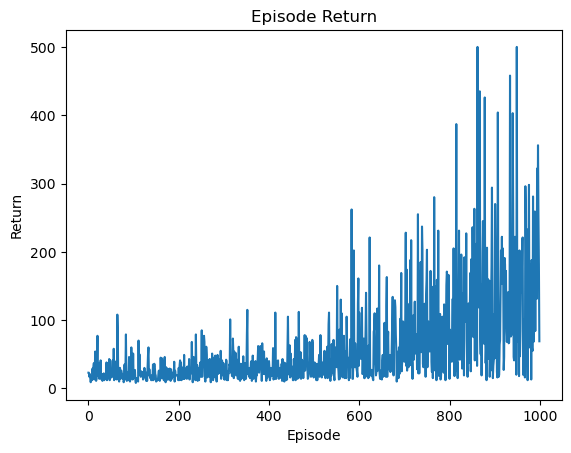

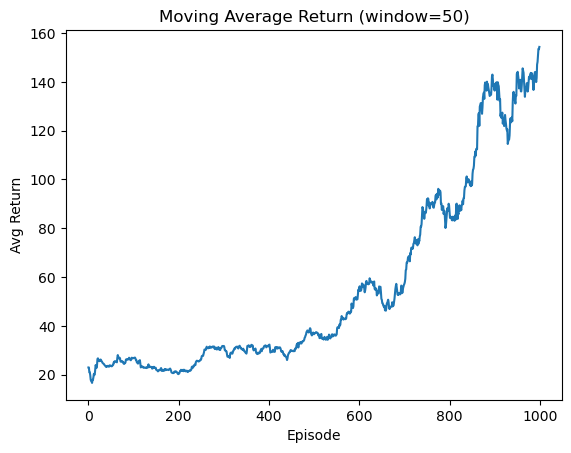

In [6]:
# Seed
seed = 2112
torch.manual_seed(seed)
np.random.seed(seed)

# Env
env = gymnasium.make('CartPole-v1')
env.reset(seed=seed)

env_render = None

pygame.display.init()

# Policy
policy = PolicyNet(env)

# TRAIN
results = reinforce(policy, env, env_render, gamma=0.98, num_episodes=1000, run_name="main_gamma098")

# Save final model
torch.save(policy.state_dict(), "final_policy_main_gamma098.pt")

# === PLOT 1: Episode Return ===
plt.figure()
plt.plot(results["episode_returns"])
plt.title("Episode Return")
plt.xlabel("Episode")
plt.ylabel("Return")

# === PLOT 2: Moving Average ===
returns = results["episode_returns"]
window = 50

moving_avg = [
    np.mean(returns[max(0, i - window): i + 1])
    for i in range(len(returns))
]

plt.figure()
plt.plot(moving_avg)
plt.title("Moving Average Return (window=50)")
plt.xlabel("Episode")
plt.ylabel("Avg Return")

plt.show()

# Close
env.close()
pygame.display.quit()

In [7]:
# And run the final agent for a few episodes.
env_render = gymnasium.make('CartPole-v1', render_mode='human')
for _ in range(10):
    run_episode(env_render, policy)
env_render.close()

In [8]:
env_eval = gymnasium.make('CartPole-v1')
policy.eval()

with torch.no_grad():
    greedy_returns = [float(sum(run_episode_greedy(env_eval, policy)[2])) for _ in range(100)]
    stochastic_returns = [float(sum(run_episode(env_eval, policy)[3])) for _ in range(100)]

print(f"Greedy     — avg: {np.mean(greedy_returns):.1f}  std: {np.std(greedy_returns):.1f}")
print(f"Stochastic — avg: {np.mean(stochastic_returns):.1f}  std: {np.std(stochastic_returns):.1f}")

env_eval.close()

Greedy     — avg: 500.0  std: 0.3
Stochastic — avg: 169.7  std: 102.4



Training with gamma = 0.9
💾 New best model saved! AvgReturn = 23.00

Episode: 0
Return: 23.00
Avg Return (last 50): 23.00
Std Return (last 50): 0.00
Episode Length: 23
Loss: 0.0198
Running Reward: 1.15


Episode: 50
Return: 16.00
Avg Return (last 50): 21.18
Std Return (last 50): 10.45
Episode Length: 16
Loss: -0.2906
Running Reward: 19.86


Episode: 100
Return: 12.00
Avg Return (last 50): 22.14
Std Return (last 50): 13.00
Episode Length: 12
Loss: -0.0988
Running Reward: 23.24

💾 New best model saved! AvgReturn = 23.84

Episode: 150
Return: 10.00
Avg Return (last 50): 23.84
Std Return (last 50): 11.40
Episode Length: 10
Loss: -0.1290
Running Reward: 24.60


Episode: 200
Return: 19.00
Avg Return (last 50): 20.56
Std Return (last 50): 11.08
Episode Length: 19
Loss: -0.0866
Running Reward: 19.70

💾 New best model saved! AvgReturn = 27.46

Episode: 250
Return: 36.00
Avg Return (last 50): 27.46
Std Return (last 50): 17.46
Episode Length: 36
Loss: 0.0991
Running Reward: 28.84


Episode: 300


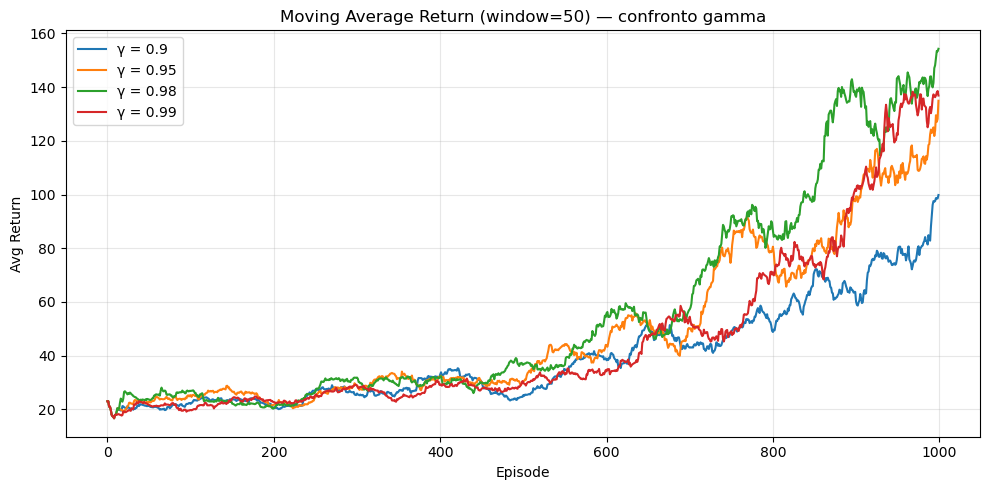


=== Riepilogo finale ===
Gamma      Avg Return (last 50)      Std (last 50)        Max Return
----------------------------------------------------------------------
0.9        98.66                     67.11                306.00
0.95       134.76                    101.80               500.00
0.98       147.38                    90.98                500.00
0.99       133.64                    87.46                461.00


In [9]:
# === Gamma experiment ===
gammas = [0.90, 0.95, 0.98, 0.99]
num_episodes_exp = 1000
seed = 2112
results_by_gamma = {}

for gamma in gammas:
    print(f"\n{'='*40}")
    print(f"Training with gamma = {gamma}")
    print(f"{'='*40}")
    
    # Reset seed per run riproducibile
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Nuova policy e ambiente freschi per ogni gamma
    env_exp = gymnasium.make('CartPole-v1')
    env_exp.reset(seed=seed)
    policy_exp = PolicyNet(env_exp)
    
    results = reinforce(
    policy_exp,
    env_exp,
    gamma=gamma,
    num_episodes=num_episodes_exp,
    run_name=f"gamma_{gamma}"
)
    results_by_gamma[gamma] = results
    
    env_exp.close()

# === Plot confronto moving average ===
window = 50
plt.figure(figsize=(10, 5))

for gamma, results in results_by_gamma.items():
    returns = results["episode_returns"]
    moving_avg = [
        np.mean(returns[max(0, i - window): i + 1])
        for i in range(len(returns))
    ]
    plt.plot(moving_avg, label=f"γ = {gamma}")

plt.title("Moving Average Return (window=50) — confronto gamma")
plt.xlabel("Episode")
plt.ylabel("Avg Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === Tabella riassuntiva ===
print("\n=== Riepilogo finale ===")
print(f"{'Gamma':<10} {'Avg Return (last 50)':<25} {'Std (last 50)':<20} {'Max Return'}")
print("-" * 70)
for gamma, results in results_by_gamma.items():
    r = results["episode_returns"]
    avg = np.mean(r[-50:])
    std = np.std(r[-50:])
    mx  = np.max(r)
    print(f"{gamma:<10} {avg:<25.2f} {std:<20.2f} {mx:.2f}")

In [10]:
# === Greedy vs Stochastic Evaluation ===

env_eval = gymnasium.make('CartPole-v1')
policy.eval()

greedy_returns = []
greedy_lengths = []

stochastic_returns = []
stochastic_lengths = []

with torch.no_grad():

    # Deterministic / greedy evaluation
    for _ in range(100):
        observations, actions, rewards = run_episode_greedy(env_eval, policy)
        greedy_returns.append(float(sum(rewards)))
        greedy_lengths.append(len(rewards))

    # Stochastic evaluation
    for _ in range(100):
        observations, actions, log_probs, rewards = run_episode(env_eval, policy)
        stochastic_returns.append(float(sum(rewards)))
        stochastic_lengths.append(len(rewards))

print(f"Greedy     — avg return: {np.mean(greedy_returns):.1f}  std: {np.std(greedy_returns):.1f}  avg length: {np.mean(greedy_lengths):.1f}")
print(f"Stochastic — avg return: {np.mean(stochastic_returns):.1f}  std: {np.std(stochastic_returns):.1f}  avg length: {np.mean(stochastic_lengths):.1f}")

env_eval.close()

Greedy     — avg return: 498.8  std: 8.3  avg length: 498.8
Stochastic — avg return: 187.9  std: 114.9  avg length: 187.9


In [11]:
# === Load and evaluate final saved model from main experiment ===

env_eval = gymnasium.make('CartPole-v1')

final_policy = PolicyNet(env_eval)

checkpoint_path = "final_policy_main_gamma098.pt"
checkpoint = torch.load(checkpoint_path, map_location="cpu")

final_policy.load_state_dict(checkpoint)
final_policy.eval()

greedy_returns = []
greedy_lengths = []

stochastic_returns = []
stochastic_lengths = []

with torch.no_grad():

    for _ in range(100):
        observations, actions, rewards = run_episode_greedy(env_eval, final_policy)
        greedy_returns.append(float(sum(rewards)))
        greedy_lengths.append(len(rewards))

    for _ in range(100):
        observations, actions, log_probs, rewards = run_episode(env_eval, final_policy)
        stochastic_returns.append(float(sum(rewards)))
        stochastic_lengths.append(len(rewards))

print(f"Greedy     — avg return: {np.mean(greedy_returns):.1f}  std: {np.std(greedy_returns):.1f}  avg length: {np.mean(greedy_lengths):.1f}")
print(f"Stochastic — avg return: {np.mean(stochastic_returns):.1f}  std: {np.std(stochastic_returns):.1f}  avg length: {np.mean(stochastic_lengths):.1f}")

env_eval.close()

Greedy     — avg return: 498.0  std: 13.9  avg length: 498.0
Stochastic — avg return: 168.5  std: 88.9  avg length: 168.5


## For your consideration

There are many things that can be improved in this example. Some things you can think about:

1. **Development Environment**. If there is *one* laboratory for which you don't use a Jupyter Notebook, *this should definitely be the one*. PyGame (for visualizing episodes in the environment) interacts very badly with the Jupyter Python kernels at times. Consider using PyCharm or VSCode.
 
2. **Better Logging**. Monitoring just a moving average return is a pretty coarse metric of performance -- one that with also *depend on the discount factor $\gamma$*. Think about what might be better statistics to collect and report, and also *how to collect and report them*. You should think about using Weights and Biases or Tensorboard for this.

3. **Checkpointing**. When training is unstable, it can be a good idea to *checkpoint* your models both periodically (so you can restart training from a specific checkpoint) and for each *best* model as determined by you running performance measure(s). 

4. **Exploration**. The model is probably overfitting (or perhaps remaining too *plastic*, which can explain the unstable convergence). Our policy is *always* stochastic in that we sample from the output distribution. It would be interesting to add a temperature parameter to the policy so that we can control this behavior, or even implement a deterministic policy sampler that always selects the action with max probability to evaluate the quality of the learned policy network.

5. **Discount Factor**: The discount factor (default $\gamma = 0.99$) is an important hyperparameter that has an effect on the stability of training. Try different values for $\gamma$ and see how it affects training. Can you think of other ways to stabilize training?